In [2]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

from tqdm.notebook import tqdm
# !pip install ipywidgets

In [3]:
import acsmuthi.utility.mathematics as mths
from acsmuthi.linear_system.coupling.substrate_coupling_matrix import substrate_coupling_block_integrate, substrate_coupling_element, substrate_coupling_block
from acsmuthi.linear_system.coupling.coupling_basics import k_contour
from acsmuthi.medium import FluidMedium, ElasticMedium, RigidBoundary, MediumSystem, fresnel_r_elastic

### spectrum

In [4]:
from acsmuthi.initial_field import PlaneWave
from acsmuthi.particles import SphericalParticle
from acsmuthi.simulation import Simulation
from acsmuthi.postprocessing.forces import all_forces

In [5]:
def two_polysterene_spheres_water_above_glycerin(ka, nmax=4):
    # Water
    RHO_MED = 1000
    C_MED = 1480
    
    # Glycerin
    RHO_SUB = 1260
    C_SUB = 1900

    # Particle
    C_PAR = 1020
    RHO_PAR = 1045
    R_PAR = 100e-6

    # Field
    K = ka / R_PAR
    FREQ = K * C_MED / 2 / np.pi
    P0 = 50e3
    DIR = np.array([0.58, 0., -0.81])
    
    pos1 = np.array([-2.2*R_PAR, 0, 3.2*R_PAR])  # [m]
    pos2 = np.array([2.2*R_PAR, 0, 3.2*R_PAR])  # [m]

    incident_field = PlaneWave(k=K, amplitude=P0, direction=DIR)

    fluid = MediumSystem([
            FluidMedium(density=RHO_MED, sound_speed_longitudinal=C_MED), 
            FluidMedium(density=RHO_SUB, sound_speed_longitudinal=C_SUB)
        ])

    particles = tuple(
        SphericalParticle(
            position=pos, 
            radius=R_PAR, 
            density=RHO_PAR, 
            sound_speed_longitudinal=C_PAR,
            multipole_order=nmax
        ) for pos in (pos1, pos2)
    )

    sim = Simulation(
        particles=np.array(particles), 
        medium=fluid, 
        initial_field=incident_field, 
        frequency=FREQ, 
        order=nmax
    )
    sim.run()

    frcs = all_forces(sim)
    return frcs

In [6]:
ka_vals = np.linspace(0.25, 2, 150)
forces = np.zeros((len(ka_vals), 2, 3))

for i, ka in enumerate(tqdm(ka_vals)):
    f = two_polysterene_spheres_water_above_glycerin(ka, nmax=4)
    forces[i] = f.copy()

  0%|          | 0/150 [00:00<?, ?it/s]

c:\Users\kvd\AppData\Local\pypoetry\Cache\virtualenvs\acsmuthi-TZOMr8Wr-py3.11\Lib\site-packages\scipy\special\_basic.py:1797: RuntimeWarning: invalid value encountered in multiply
  pd = pd * fixarr


### water glycerin

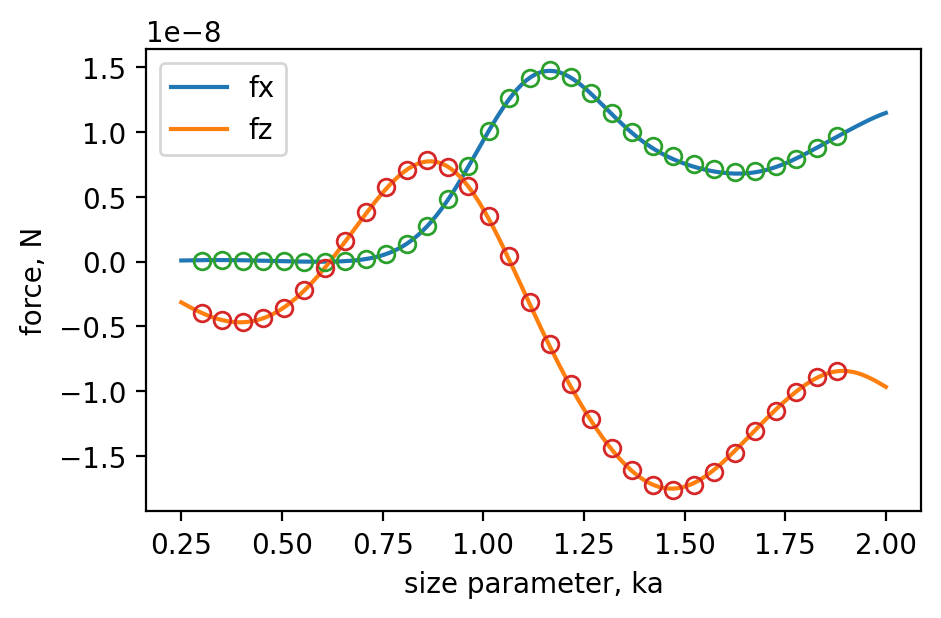

In [7]:
comsol_tab = np.loadtxt(".\\testing_examples\\tables\\comsol\\2pwg_ka_32_comsol.csv", delimiter=",", skiprows=5, dtype=float)

fx_comsol = comsol_tab[1:, 3]
fz_comsol = comsol_tab[1:, 4]
ka_comsol = comsol_tab[1:, 2]

fig, ax = plt.subplots(1, figsize=(5, 3))
fig.subplots_adjust(wspace=0.1)

ax.plot(ka_vals, forces[:, 0, 0], label='fx')
ax.plot(ka_vals, forces[:, 0, 2], label='fz')
ax.plot(ka_comsol, fx_comsol, linestyle='', marker='o', mfc='none')
ax.plot(ka_comsol, fz_comsol, linestyle='', marker='o', mfc='none')

ax.legend()
ax.set(xlabel="size parameter, ka", ylabel="force, N")
plt.show()

### elastic

In [8]:
def two_polysterene_spheres_water_above_quartz(ka, nmax=4):
    # Water
    RHO_MED = 1000
    C_MED = 1480
    
    # Quartz
    RHO_SUB = 2650
    CL_SUB = 5900
    CT_SUB = 3400

    # Particle
    C_PAR = 1020
    RHO_PAR = 1045
    R_PAR = 100e-6

    # Field
    K = ka / R_PAR
    FREQ = K * C_MED / 2 / np.pi
    P0 = 50e3
    DIR = np.array([0, 0., -1])
    
    pos1 = np.array([-2.2*R_PAR, 0, 3.2*R_PAR])  # [m]
    pos2 = np.array([2.2*R_PAR, 0, 3.2*R_PAR])  # [m]

    incident_field = PlaneWave(k=K, amplitude=P0, direction=DIR)

    fluid = MediumSystem([
            FluidMedium(density=RHO_MED, sound_speed_longitudinal=C_MED), 
            ElasticMedium(density=RHO_SUB, sound_speed_longitudinal=CL_SUB, sound_speed_transversal=CT_SUB)
        ])

    particles = tuple(
        SphericalParticle(
            position=pos, 
            radius=R_PAR, 
            density=RHO_PAR, 
            sound_speed_longitudinal=C_PAR,
            multipole_order=nmax
        ) for pos in (pos1, pos2)
    )

    # k_sub_branchs = np.array([fluid.substrate.wavenumber(FREQ), fluid.substrate.wavenumber_transversal(FREQ)])
    # k_parallel = k_contour(
    #     imag_deflection=1e-2,
    #     step=1e-2,
    #     problems=k_sub_branchs / fluid.sur_medium.wavenumber(FREQ),
    #     finish=10,
    # ) * fluid.sur_medium.wavenumber(FREQ)
    
    sim = Simulation(
        particles=np.array(particles), 
        medium=fluid, 
        initial_field=incident_field, 
        frequency=FREQ, 
        order=nmax,
        k_parallel=None #k_parallel
    )
    sim.run()

    frcs = all_forces(sim)
    return frcs

In [9]:
ka_vals = np.linspace(0.75, 1.75, 35)
forces = np.zeros((len(ka_vals), 2, 3))

for i, ka in enumerate(tqdm(ka_vals)):
    f = two_polysterene_spheres_water_above_quartz(ka, nmax=4)
    forces[i] = f.copy()

  0%|          | 0/35 [00:00<?, ?it/s]

### water quartz

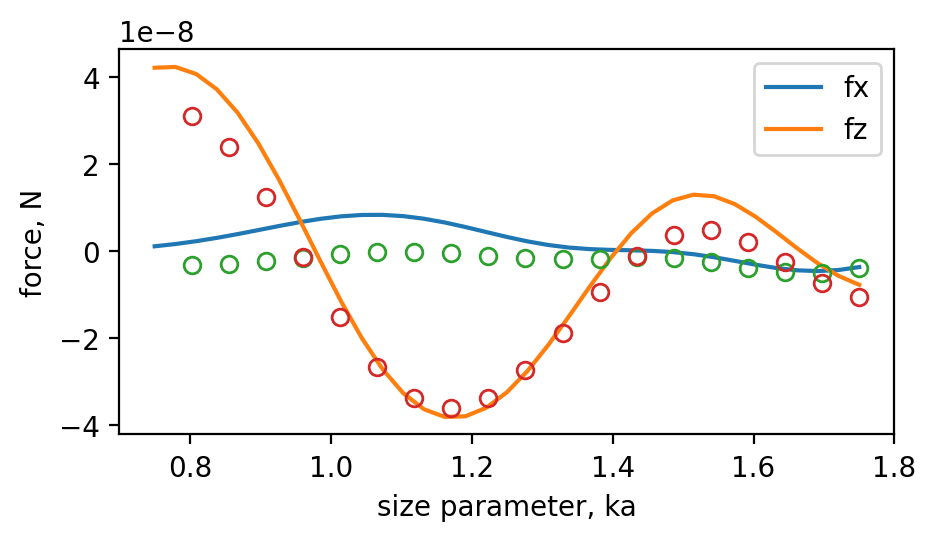

In [11]:
comsol_tab = np.loadtxt(".\\testing_examples\\tables\\comsol\\2pwq_ka_32_comsol_big.csv", delimiter=",", skiprows=5, dtype=float)

ka_comsol = comsol_tab[1:, 3]
fx_comsol = comsol_tab[1:, 1]
fz_comsol = comsol_tab[1:, 2]

fig, ax = plt.subplots(1, figsize=(5, 2.5))
fig.subplots_adjust(wspace=0.1)

ax.plot(ka_vals, forces[:, 1, 0], label='fx')
ax.plot(ka_vals, forces[:, 1, 2], label='fz')
ax.plot(ka_comsol, fx_comsol, linestyle='', marker='o', mfc='none')
ax.plot(ka_comsol, fz_comsol, linestyle='', marker='o', mfc='none')

ax.legend()
ax.set(xlabel="size parameter, ka", ylabel="force, N")
plt.show()

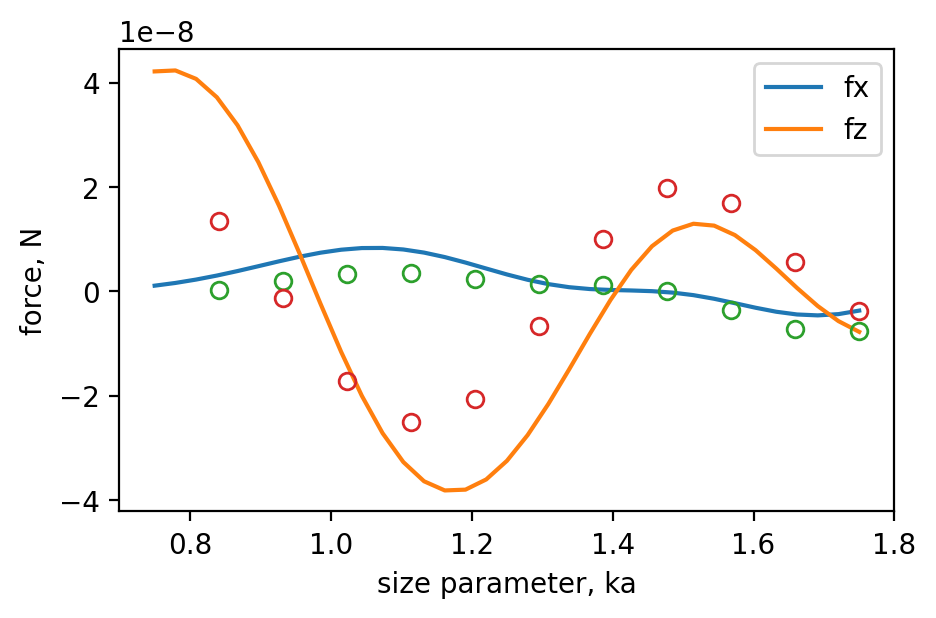

In [ ]:
# periodoc conditions
comsol_tab = np.loadtxt(".\\testing_examples\\tables\\comsol\\2pwq_ka_32_comsol.csv", delimiter=",", skiprows=5, dtype=float)

ka_comsol = comsol_tab[1:, 1]
fx_comsol = comsol_tab[1:, 2]
fz_comsol = comsol_tab[1:, 3]

fig, ax = plt.subplots(1, figsize=(5, 3))
fig.subplots_adjust(wspace=0.1)

ax.plot(ka_vals, forces[:, 1, 0], label='fx')
ax.plot(ka_vals, forces[:, 1, 2], label='fz')
ax.plot(ka_comsol, fx_comsol, linestyle='', marker='o', mfc='none')
ax.plot(ka_comsol, fz_comsol, linestyle='', marker='o', mfc='none')

ax.legend()
ax.set(xlabel="size parameter, ka", ylabel="force, N")
plt.show()

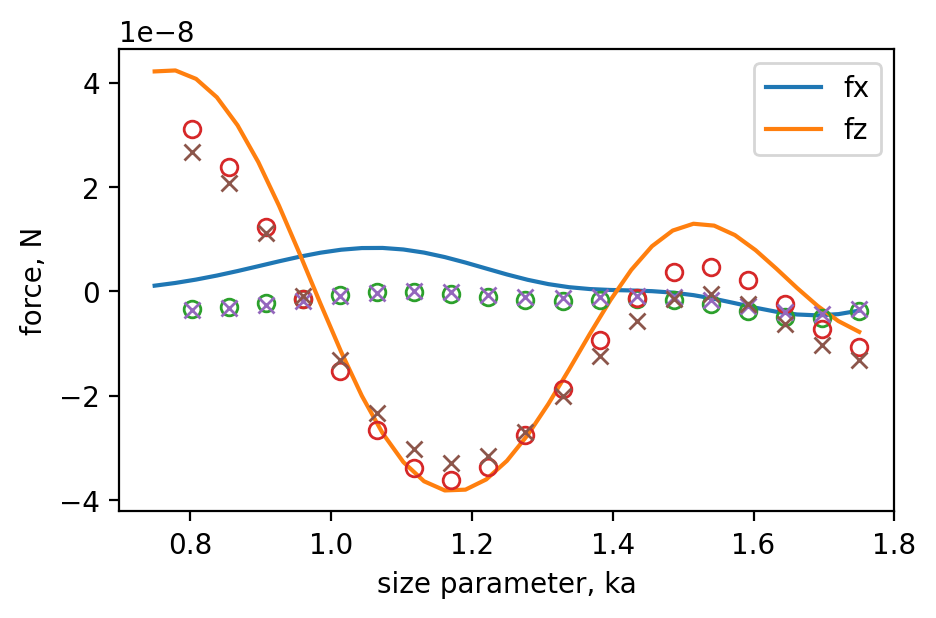

In [ ]:
# a little increased domain (depth)

comsol_tab = np.loadtxt(".\\testing_examples\\tables\\comsol\\2pwq_ka_32_comsol_big.csv", delimiter=",", skiprows=5, dtype=float)

ka_comsol = comsol_tab[1:, 3]
fx_comsol = comsol_tab[1:, 1]
fz_comsol = comsol_tab[1:, 2]

fig, ax = plt.subplots(1, figsize=(5, 3))
fig.subplots_adjust(wspace=0.1)

ax.plot(ka_vals, forces[:, 1, 0], label='fx')
ax.plot(ka_vals, forces[:, 1, 2], label='fz')
ax.plot(ka_comsol, fx_comsol, linestyle='', marker='o', mfc='none')
ax.plot(ka_comsol, fz_comsol, linestyle='', marker='o', mfc='none')

comsol_tab = np.loadtxt(".\\testing_examples\\tables\\comsol\\2pwq_ka_32_comsol_bigg_t.csv", delimiter=",", skiprows=5, dtype=float)

ka_comsol = comsol_tab[1:, 3]
fx_comsol = comsol_tab[1:, 1]
fz_comsol = comsol_tab[1:, 2]

ax.plot(ka_comsol, fx_comsol, linestyle='', marker='x')
ax.plot(ka_comsol, fz_comsol, linestyle='', marker='x')

ax.legend()
ax.set(xlabel="size parameter, ka", ylabel="force, N")
plt.show()

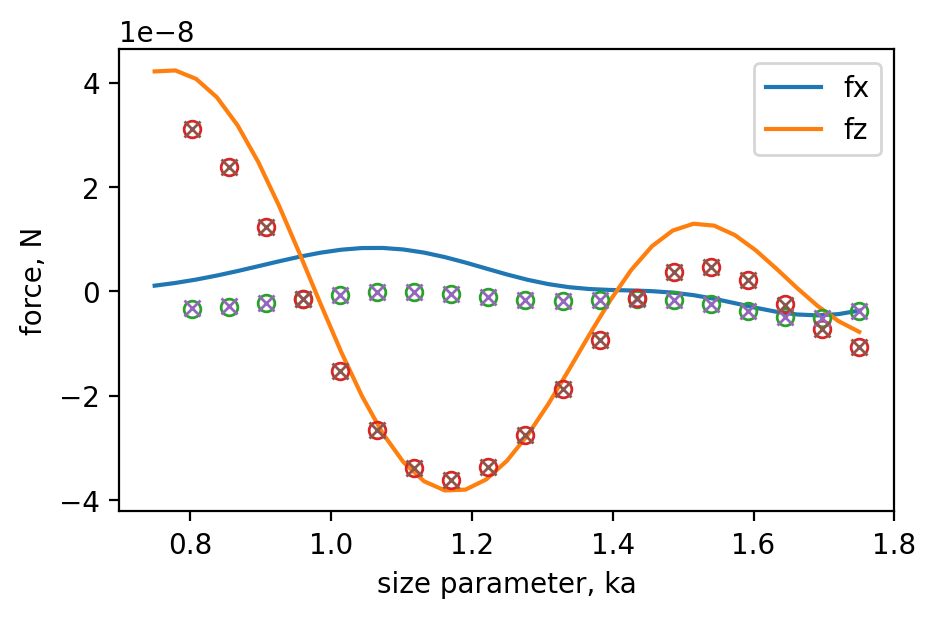

In [ ]:
# lambda/5 -> lambda/7
comsol_tab = np.loadtxt(".\\testing_examples\\tables\\comsol\\2pwq_ka_32_comsol_big.csv", delimiter=",", skiprows=5, dtype=float)

ka_comsol = comsol_tab[1:, 3]
fx_comsol = comsol_tab[1:, 1]
fz_comsol = comsol_tab[1:, 2]

fig, ax = plt.subplots(1, figsize=(5, 3))
fig.subplots_adjust(wspace=0.1)

ax.plot(ka_vals, forces[:, 1, 0], label='fx')
ax.plot(ka_vals, forces[:, 1, 2], label='fz')
ax.plot(ka_comsol, fx_comsol, linestyle='', marker='o', mfc='none')
ax.plot(ka_comsol, fz_comsol, linestyle='', marker='o', mfc='none')

comsol_tab = np.loadtxt(".\\testing_examples\\tables\\comsol\\2pwq_ka_32_comsol_bi7_t.csv", delimiter=",", skiprows=5, dtype=float)

ka_comsol = comsol_tab[1:, 3]
fx_comsol = comsol_tab[1:, 1]
fz_comsol = comsol_tab[1:, 2]

ax.plot(ka_comsol, fx_comsol, linestyle='', marker='x')
ax.plot(ka_comsol, fz_comsol, linestyle='', marker='x')

ax.legend()
ax.set(xlabel="size parameter, ka", ylabel="force, N")
plt.show()

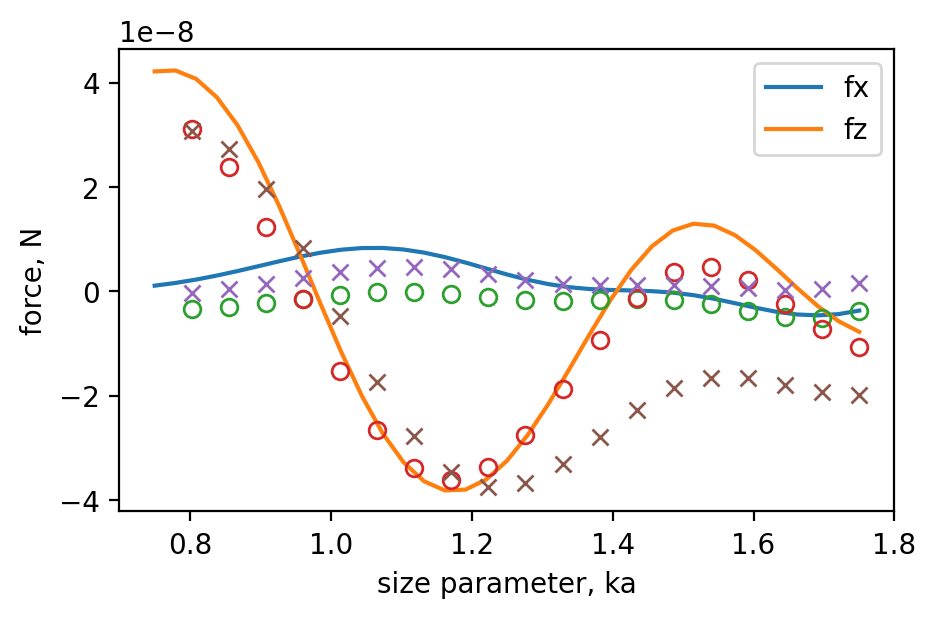

In [ ]:
# decreased domain size
comsol_tab = np.loadtxt(".\\testing_examples\\tables\\comsol\\2pwq_ka_32_comsol_big.csv", delimiter=",", skiprows=5, dtype=float)

ka_comsol = comsol_tab[1:, 3]
fx_comsol = comsol_tab[1:, 1]
fz_comsol = comsol_tab[1:, 2]

fig, ax = plt.subplots(1, figsize=(5, 3))
fig.subplots_adjust(wspace=0.1)

ax.plot(ka_vals, forces[:, 1, 0], label='fx')
ax.plot(ka_vals, forces[:, 1, 2], label='fz')
ax.plot(ka_comsol, fx_comsol, linestyle='', marker='o', mfc='none')
ax.plot(ka_comsol, fz_comsol, linestyle='', marker='o', mfc='none')

comsol_tab = np.loadtxt(".\\testing_examples\\tables\\comsol\\2pwq_ka_32_comsol_small.csv", delimiter=",", skiprows=5, dtype=float)

ka_comsol = comsol_tab[1:, 3]
fx_comsol = comsol_tab[1:, 1]
fz_comsol = comsol_tab[1:, 2]

ax.plot(ka_comsol, fx_comsol, linestyle='', marker='x')
ax.plot(ka_comsol, fz_comsol, linestyle='', marker='x')

ax.legend()
ax.set(xlabel="size parameter, ka", ylabel="force, N")
plt.show()

### r comsol

In [15]:
water = FluidMedium(density=1000, sound_speed_longitudinal=1480)
quartz = ElasticMedium(density=2650, sound_speed_longitudinal=5900, sound_speed_transversal=3400)
wq = MediumSystem([water, quartz])

angs = np.linspace(0, 55, 255)
k_pars = water.wavenumber(1000) * np.sin(np.deg2rad(angs)) - 1e-15j
refl = abs(wq.fresnel_r(k_pars, 1000))

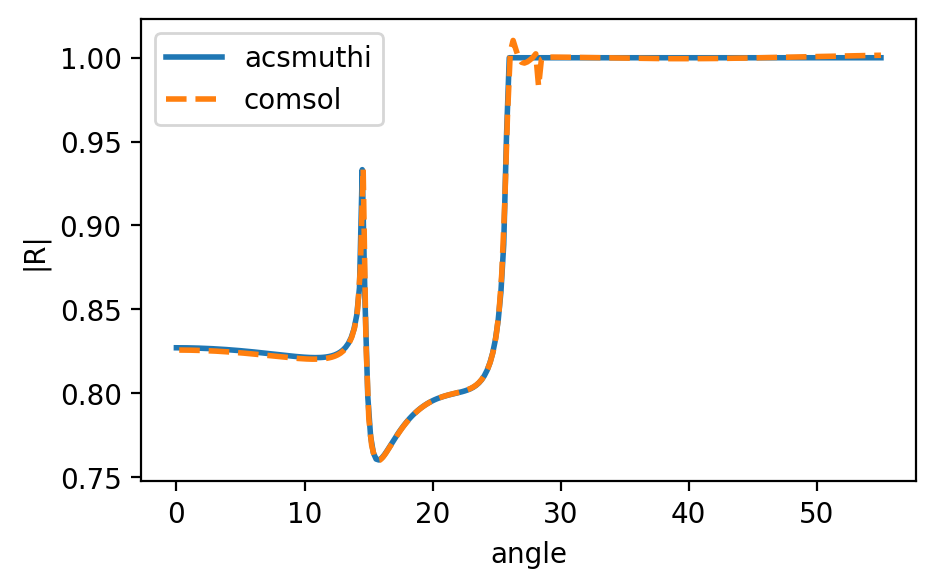

In [16]:
comsol_tab = np.loadtxt(".\\testing_examples\\tables\\comsol\\reflection_wq_angle_comsol.csv", delimiter=",", skiprows=5, dtype=float)

angs_comsol = comsol_tab[1:, 0]
refl_comsol = comsol_tab[1:, 1]

fig, ax = plt.subplots(1, figsize=(5, 3))
fig.subplots_adjust(wspace=0.1)

ax.plot(angs, refl, lw=2, label='acsmuthi')
ax.plot(angs_comsol, refl_comsol, ls='--', lw=2, label='comsol')

ax.legend()
ax.set(xlabel="angle", ylabel="|R|")
plt.show()